In [120]:
import h5py
import numpy
from regina import Triangulation3

from pachner_traversal.utils import data_root
import matplotlib.pyplot as plt
import numpy as np

In [74]:
with h5py.File(
    data_root / "input_data" / "dehydration" / "processed" / "spheres_10.hdf5", "r"
) as f:
    isos = f['isos'].asstr()[:]
    count_3_deg_folded = f['count_3_deg_folded'][:]
    count_3_deg_regular = f['count_3_deg_regular'][:]
    coutn_3_deg = f['count_3_deg'][:]

In [115]:
def compute_potential_regular_edges(iso: str) -> float:
    tri = Triangulation3.rehydrate(iso)
    potential_val = 0.0

    for edge in tri.edges():
        unique_tets = []
        for emb in edge.embeddings():
            unique_tets.append(emb.simplex().index())
        if len(set(unique_tets)) == edge.degree():
            unit_degree = 1.0
        else:
            unit_degree = 0.0
        potential_val = potential_val + unit_degree

    return potential_val

In [125]:
reg_edges = [compute_potential_regular_edges(iso) for iso in isos[:10_000]]

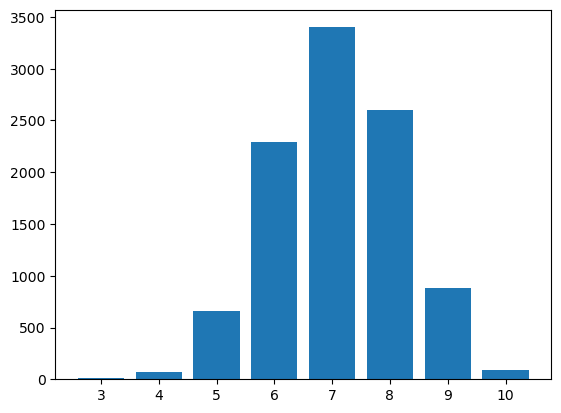

In [126]:
plt.bar(np.unique(reg_edges, return_counts=True)[0], np.unique(reg_edges, return_counts=True)[1])
plt.show()